In [ ]:
# Requires a kaggle.json API token in ~/.kaggle/ 
# Get yours at: https://www.kaggle.com/settings -> API -> Create New Token

In [6]:
!pip install kaggle xgboost optuna mlflow scikit-learn joblib fastapi uvicorn lightgbm -q

In [4]:
!kaggle datasets download -d mlg-ulb/creditcardfraud --unzip --force

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100%|█████████████████████████████████████| 66.0M/66.0M [00:01<00:00, 41.6MB/s]



In [7]:
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb


In [8]:
df = pd.read_csv("creditcard.csv")

In [9]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [10]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [12]:
df["Class"].value_counts()
percent_of_fraud = (492/(284315+492)) * 100
print(percent_of_fraud)

0.1727485630620034


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df["Hour"] = (df["Time"]//3600) % 24
df = df.drop("Time", axis=1)

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train[["Amount"]] = scaler.fit_transform(X_train[["Amount"]])
X_test[["Amount"]] = scaler.fit_transform(X_test[["Amount"]])

In [14]:
df_train = X_train.copy()
df_train["Class"] = y_train

corr_matrix = df_train.corr()

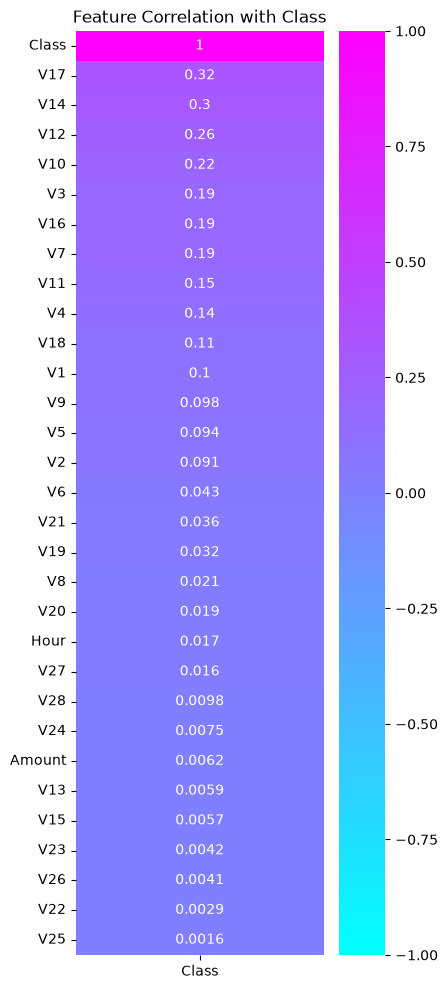

In [15]:
class_corr = corr_matrix['Class'].abs().sort_values(ascending=False).to_frame()

# Plot heatmap
plt.figure(figsize=(4, 12))
sns.heatmap(class_corr, annot=True, cmap='cool', vmin=-1, vmax=1)
plt.title('Feature Correlation with Class')
plt.show()

In [18]:
n=12
class_corr_features = class_corr.drop('Class', errors='ignore') 
features = class_corr_features.head(n).index.tolist()
X_train = X_train[features]
X_test = X_test[features]

In [14]:
# == RANDOM FOREST CLASSIFIER MODEL ==
import time
from sklearn.ensemble import RandomForestClassifier
# class_weight as balanced to penalize a missed fraud instance
rfc = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)

start = time.time()
rfc.fit(X_train, y_train)
train_time = time.time() - start
print(f"Training time: {train_time:.2f} seconds")

Training time: 95.25 seconds


In [47]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, classification_report, confusion_matrix

pred_start = time.time()
threshold = 0.15
rfc_probs = rfc.predict_proba(X_test)[:,1]
rfc_pred = (rfc_probs >= threshold).astype(int)
pred_time = time.time() - pred_start
print(f"Prediction time: {pred_time:.2f} seconds")
rfc_classification_report = classification_report(y_test, rfc_pred)

print(rfc_classification_report)

Prediction time: 0.24 seconds
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.86      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [16]:
confus_matrix = confusion_matrix(y_test, rfc_pred)
print(confus_matrix)

[[56849    15]
 [   15    83]]


In [17]:
import xgboost as xgb

ratio = sum(y_train==0) / sum(y_train==1)

# using a scale_pos_weight to penalize missed fraud instances
xgb_model = xgb.XGBClassifier(n_estimators=100, scale_pos_weight=ratio, random_state=42)

start = time.time()
xgb_model.fit(X_train, y_train)
train_time = time.time() - start
print(f"Training time: {train_time:.2f} seconds")

Training time: 2.11 seconds


In [46]:
pred_start = time.time()
xgb_probs = xgb_model.predict_proba(X_test)[:,1]
xgb_pred = (xgb_probs >= threshold).astype(int)
pred_time = time.time() - pred_start
print(f"Prediction time: {pred_time:.2f} seconds")
xgb_classification_report = classification_report(y_test, xgb_pred)

print(xgb_classification_report)

Prediction time: 0.31 seconds
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     56864
           1       0.02      0.93      0.05        98

    accuracy                           0.94     56962
   macro avg       0.51      0.93      0.51     56962
weighted avg       1.00      0.94      0.97     56962



In [19]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, class_weight='balanced', random_state=42, n_jobs=-1)

start = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start
print(f"Training time: {train_time:.2f} seconds")

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025575 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3060
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training time: 11.24 seconds


In [20]:
pred_start = time.time()
lgbm_probs = lgbm.predict_proba(X_test)[:,1]
lgbm_pred = (lgbm_probs >= threshold).astype(int)
pred_time = time.time() - pred_start
print(f"Prediction time: {pred_time:.2f} seconds")
lgbm_classification_report = classification_report(y_test, lgbm_pred)

print(lgbm_classification_report)

Prediction time: 1.40 seconds
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.87      0.83        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962



##Model Choice: XGBoost


*   Highest recall (same as LightGBM)
*   BUT it is way faster



In [21]:
import optuna

def objective(trials):
  params = {"n_estimators": trials.suggest_int("n_estimators", 300,800),
            "learning_rate": trials.suggest_float("learning_rate", 0.01,0.2),
            "max_depth": trials.suggest_int("max_depth", 3,10),
            "subsample": trials.suggest_float("subsample", 0.5,1.0),
            "colsample_bytree": trials.suggest_float("colsample_bytree", 0.5,1.0),
            "min_child_weight": trials.suggest_int("min_child_weight", 1,10),
            "gamma": trials.suggest_float("gamma", 0,5),
            "reg_alpha": trials.suggest_float("reg_alpha", 0,5),
            "reg_lambda": trials.suggest_float("reg_lambda", 0,5),
            "random_state": 42,
            "n_jobs": -1,
            "scale_pos_weight": sum(y_train==0) / sum(y_train==1),
            "eval_metric": 'logloss'}

  model = xgb.XGBClassifier(**params)
  model.fit(X_train, y_train)
  prob = model.predict_proba(X_test)[:,1]
  y_pred = (prob >= threshold).astype(int)
  res = recall_score(y_test, y_pred, pos_label=1)
  return res

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40)

print(f"Best Recalls: {study.best_value}")
print(f"Best Params: {study.best_params}")

[I 2026-07-02 08:56:55,931] A new study created in memory with name: no-name-571d79c3-fd22-4c87-bf28-fdd131210292
[I 2026-07-02 08:57:01,975] Trial 0 finished with value: 0.8775510204081632 and parameters: {'n_estimators': 351, 'learning_rate': 0.048241382003465415, 'max_depth': 6, 'subsample': 0.7690657701754882, 'colsample_bytree': 0.7237964026745207, 'min_child_weight': 5, 'gamma': 2.920477347484161, 'reg_alpha': 3.5827153098440583, 'reg_lambda': 1.1141833090439164}. Best is trial 0 with value: 0.8775510204081632.
[I 2026-07-02 08:57:09,448] Trial 1 finished with value: 0.8775510204081632 and parameters: {'n_estimators': 429, 'learning_rate': 0.1092037264585353, 'max_depth': 8, 'subsample': 0.8584059822547158, 'colsample_bytree': 0.8260655863666971, 'min_child_weight': 5, 'gamma': 0.7382985700087746, 'reg_alpha': 2.7049243502251343, 'reg_lambda': 1.4484162818175939}. Best is trial 0 with value: 0.8775510204081632.
[I 2026-07-02 08:57:20,631] Trial 2 finished with value: 0.8877551020

Best Recalls: 0.9183673469387755
Best Params: {'n_estimators': 402, 'learning_rate': 0.031908277922867045, 'max_depth': 3, 'subsample': 0.6588866212378575, 'colsample_bytree': 0.7463376516496845, 'min_child_weight': 8, 'gamma': 1.8749823115476905, 'reg_alpha': 1.6897037936766581, 'reg_lambda': 1.615739414166045}


In [22]:
ratio = sum(y_train==0) / sum(y_train==1)

best_params = study.best_params
best_params.update({"random_state": 42, "scale_pos_weight": ratio, "n_jobs": -1, "eval_metric": "logloss",})
xgb_model = xgb.XGBClassifier(**best_params)

start = time.time()
xgb_model.fit(X_train, y_train)
train_time = time.time() - start
print(f"Training time: {train_time:.2f} seconds")

pred_start = time.time()
xgb_probs = xgb_model.predict_proba(X_test)[:,1]
xgb_pred = (xgb_probs >= threshold).astype(int)
pred_time = time.time() - pred_start
print(f"Prediction time: {pred_time:.2f} seconds")
xgb_classification_report = classification_report(y_test, xgb_pred)

print(xgb_classification_report)

Training time: 4.84 seconds
Prediction time: 0.32 seconds
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [41]:
import mlflow
import mlflow.sklearn

with mlflow.start_run():
  ratio = sum(y_train==0) / sum(y_train==1)
  best_params = study.best_params
  best_params.update({"random_state": 42, "scale_pos_weight": ratio, "n_jobs": -1, "eval_metric": "logloss",})
  mlflow.log_params(best_params)

  final_model = xgb.XGBClassifier(**best_params)

  start = time.time()
  final_model.fit(X_train, y_train)
  train_time = time.time() - start
  mlflow.log_metric("train_time", train_time)

  pred_start = time.time()
  final_probs = final_model.predict_proba(X_test)[:,1]
  final_pred = (final_probs >= threshold).astype(int)
  pred_time = time.time() - pred_start
  mlflow.log_metric("pred_time", pred_time)

  precision = precision_score(y_test, final_pred, pos_label=1)
  recall = recall_score(y_test, final_pred, pos_label=1)
  f1 = f1_score(y_test, final_pred, pos_label=1)

  mlflow.log_metric("precision", precision)
  mlflow.log_metric("recall", recall)
  mlflow.log_metric("f1", f1)

  mlflow.xgboost.log_model(xgb_model, "model")
  print(f"Precision: {precision:.2f}")
  print(f"Recall: {recall:.2f}")
  print(f"F1: {f1:.2f}")

2026/07/02 09:32:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Precision: 0.06
Recall: 0.92
F1: 0.12


In [43]:
import joblib
import os

os.makedirs("models", exist_ok=True)
joblib.dump(final_model, "models/xgb_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

[![Open In Colab](https://google.com)](https://google.com)

In [1]:
print(features)

NameError: name 'features' is not defined